# Retrieving and Aggregating AORC Data for an Area
## Latitude and Longitude grid data

**Authors:** 

<ul style="line-height:1.5;">
<li>Homa Salehabadi <a href="mailto:homa.salehabadi@usu.edu">(homa.salehabadi@usu.edu)</a></li>
<li>David Tarboton <a href="mailto:david.tarboton@usu.edu">(david.tarboton@usu.edu)</a></li>
<li>Ayman Nassar <a href="mailto:ayman.nassar@usu.edu">(ayman.nassar@usu.edu)</a></li>
<li>Anthony Castronova <a href="acastronova@cuahsi.org">(acastronova@cuahsi.org)</a></li>
<li>Pabitra Dash <a href="mailto:pabitra.dash@usu.edu">(pabitra.dash@usu.edu)</a></li>
</ul>

**Last Updated:** 7/22/2025

**Purpose:**

This notebook provides code examples for retrieving NOAA Analysis of Record for Calibration (AORC) data from Amazon Web Services (AWS). It is intended to make it easy for researchers to access data for a specific spatial domain specified by a shapefile. It also allows for data aggregation at time scales different from the underlying NOAA data.

**Audience:**

Researchers who are familiar with Jupyter Notebooks, basic Python, and basic hydrologic data analysis.

**Description:**

This notebook takes as inputs a shapefile of a specific location, start and end dates for the desired period, a variable name, and a preferred time aggregation interval. It then retrieves data from Amazon Web Services, aggregates it over the specified time interval and individual shapes within the input shapefile, saves the data as a comma separated variable (CSV) file, and visualize it. 

**Data Description:**

This notebook uses AORC data developed and published by NOAA on Amazon Web Services as described in detail in this registry of open data entry <https://registry.opendata.aws/noaa-nws-aorc/>. The AORC dataset is a gridded record of near-surface weather conditions covering the continental United States and Alaska and their hydrologically contributing areas. It is defined on a latitude/longitude spatial grid with a mesh length of 30 arc seconds (~800 m), and a temporal resolution of one hour. This notebook uses the Zarr format files of version 1.1 of the AORC data, located at `s3://noaa-nws-aorc-v1-1-1km`. Zarr is a format for storage of chunked, compressed, N-dimensional arrays, designed to support storage using distributed systems such as cloud object stores (<https://zarr.dev/>).

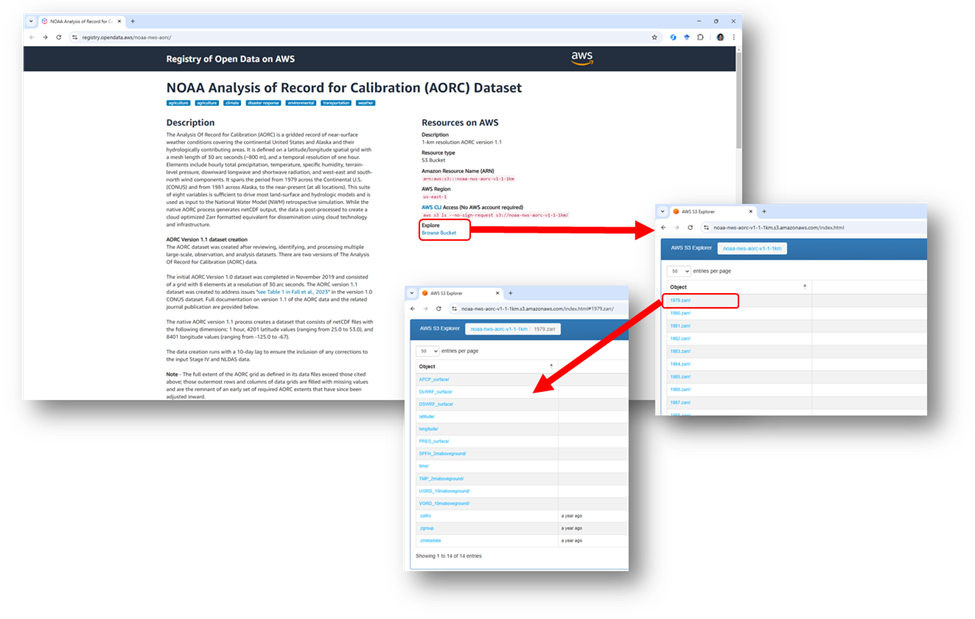


**Software Requirements:**

This notebook uses a number of Python libraries, which are imported in the first cell below. If any of these libraries are not installed, you may need to install them. If installing them results in problems due to package conflicts, we recommend setting up a Conda environment to run this notebook. The notebook [CondaEnvironmentSetup](./conda_env/CondaEnvironmentSetup.ipynb) has been provided to do this for you. Once you have set up the Conda environment, you will need to switch the kernel being used to execute this notebook to the new Conda environment: use *Python [cond env:.conda-aorc]* if this kernel is in the list, otherwise, use *Python3 (AORC)*.   


### 1. Import the Libraries

Import the libraries needed to run this notebook:

In [ ]:
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import s3fs
import warnings
from shapely.geometry import box
from datetime import datetime
from exactextract import exact_extract
from aorc_utils import get_aggregation_code, display_shapefile_map, da_animate

### 2. Set Inputs

In the next cell, set values that specify which data to retrieve.  Note that a shapefile holding Great Salt Lake subbasins has been provided with this resource. Add your own shapefile and provide the path to its location to retrieve data for a different location.

Variables available:

|Variable Name|Common Name|Description|
|---|---|---|
| APCP_surface | Total Precipitation | Hourly total precipitation (kgm-2 or mm) |
| TMP_2maboveground | Air Temperature | Temperature (at 2 m above-ground-level (AGL)) (K) |
| SPFH_2maboveground | Specific Humidity | Specific humidity (at 2 m AGL) (g g-1) |
| DLWRF_surface | Downward Long-Wave Radiation Flux | longwave (infrared) radiation flux (at the surface) (W m-2) |
| DSWRF_surface | Downward Short-Wave Radiation Flux | Downward shortwave (solar) radiation flux (at the surface) (W m-2) |
| PRES_surface | Pressure| Air pressure (at the surface) (Pa) |
| UGRD_10maboveground | U-Component of Wind | (west to east) - components of the wind (at 10 m AGL) (m s-1) |
| VGRD_10maboveground | V-Component of Wind | (south to north) - components of the wind (at 10 m AGL) (m s-1)|

Enter the Variable Name for the variable to retrieve in the cell below.

In [ ]:
# Start date - In Year-Month-Day format the earliest start date can be '1979-02-01'
start_datetime = '2020-01-01'

# End date - In Year-Month-Day format the latest end date can be '2023-01-31'
end_datetime = '2020-12-31'

# File path to the shapefile
shapefile_path = "./GSLSubbasins/GSLSubbasins.shp"

# Basin name (this will be used on the maps and plots)
basin_name = "Great Salt Lake Basin"

# Variable name to retrieve data (look at the following table for valid variable names)
variable_name = 'APCP_surface'

# User-defined aggregation interval - valid values are 'hour','day','month','year'
agg_interval = 'month'

### 3. Read Shapefile and Display Map

Read the shapefile of the defined basin using the GeoPandas library. 

In [ ]:
# Read the shapefile
gdf = gpd.read_file(shapefile_path)

Optional: Render a simple map to show the location of the basin. This is done using the `display_shapefile_map` function defined in aorc_utils.py to first plot the input basin defined above using the GeoPandas library, and then adding a basemap using the Contextily library. This is not needed for extraction of the data at the input location but serves as a check on the input location.

In [ ]:
# Display shapefile and map (optional)
display_shapefile_map(gdf, basin_name)

### 4. Load the Data

The AORC dataset we will be loading is in the Zarr format and is hosted on Amazon S3 at `s3://noaa-nws-aorc-v1-1-1km`. This dataset is organized first by years and then by variables. Due to its large size, downloading the entire dataset is impractical. Instead, the `s3fs` library (<https://s3fs.readthedocs.io/en/latest/api.html>) is used to create a connection to the Amazon S3 bucket, enabling reading data directly from S3 without downloading it. The `xarray` library is then used to reference and “lazily” retrieve only the parts that are needed. This works by reading a minimal set of metadata that will enable us to define analysis operations.

The following code loads data for the specified years and variable of interest into an Xarray DataArray, which we then use to subset and aggregate the data for the specified location, period, and time interval.

In [ ]:
## Create a list of years to retrieve data 
start_yr = datetime.strptime(start_datetime, '%Y-%m-%d').year
end_yr = datetime.strptime(end_datetime, '%Y-%m-%d').year
yrs = list(range(start_yr, end_yr+1))

## Loading data (AORC data are organized by years, look at https://noaa-nws-aorc-v1-1-1km.s3.amazonaws.com/index.html)
# Base URL
base_url = f's3://noaa-nws-aorc-v1-1-1km'
# Creating a connection to Amazon S3 bucket using the s3fs library (https://s3fs.readthedocs.io/en/latest/api.html).
s3_out = s3fs.S3FileSystem(anon=True)              # access S3 as if it were a file system. 
fileset = [s3fs.S3Map(                             # maps each year's Zarr dataset from S3 to a local-like object.
            root=f"s3://{base_url}/{yr}.zarr",     # Zarr dataset for each year
            s3=s3_out,                             # connection
            check=False                            # checking if the dataset exists before trying to load it
        ) for yr in yrs]                           # loops through each year

## Load data for specified years and veriable of interest using the xarray library
ds_yrs = xr.open_mfdataset(fileset, engine='zarr')
da_yrs_var = ds_yrs[variable_name]
variable_long_name = da_yrs_var.attrs.get('long_name')
da_yrs_var

### 5. Check Coordinate Reference System (CRS)

Use the following cell to check the Coordinate Reference System (CRS) of the shapefile and reproject it if it does not match the dataset CRS. The AORC data uses EPSG:4326 coordinate system, which corresponds to the World Geodetic System 1984 (WGS84) geographic latitude and longitude reference system. EPSG codes are widely used to define coordinate systems and can be found at <https://spatialreference.org/>. 

In [ ]:
data_crs = da_yrs_var.rio.crs
if gdf.crs == data_crs:
    print(f"CRS of Data and Shapefile --->  {data_crs}")

# Reproject shapefile if needed
if gdf.crs != data_crs:
    print(f'Original Shapefile CRS --->  {gdf.crs}')
    gdf = gdf.to_crs(data_crs)
    print(f'CRS of Data and Reprojected Shapefile  --->  {data_crs}')

To calculate basin and sunbasin areas, project the shapefile to the ESRI:102008 coordinate system, which corresponds to North America Albers Equal Area Conic coordinate system (<https://spatialreference.org/ref/esri/102008/>). The subbasin areas will be used in the next step for zonal aggregation. 

In [ ]:
## Project shapefile to North_America_Albers_Equal_Area_Conic "ESRI:102008" https://spatialreference.org/ref/esri/102008/
gdf_projected = gdf.to_crs("ESRI:102008" )  

## Compute area in the projected CRS
gdf_projected['Projected_Area_km2'] = gdf_projected['geometry'].area/ 10**6  # Area in square kilometers
total_area = gdf_projected['Projected_Area_km2'].sum()
print(f'Total {basin_name} Area is {total_area} km2')
gdf_projected

### 6. Subset and Aggregate the Data Across Time and Space

#### 6.1. Temporal Aggregation

In the following cell, we retrieve data for the defined area and aggregates it in time to the user-defined time scale (the input AORC data has an hourly time step). The output is a DataArray called `da_over_area`, which contains the temporally aggregated subset over the entire area.

In [ ]:
## Aggregation time interval
agg_code = get_aggregation_code(agg_interval)

## Retrive units
units = da_yrs_var.attrs.get('units', 'No units specified')

## Retrieve data for the bounding box first for efficiency, then clip the data for the basin.
bounding_box = box(*gdf.total_bounds)
x_min, y_min, x_max, y_max = bounding_box.bounds
da_bbox = da_yrs_var.sel(latitude=slice(y_min, y_max), longitude=slice(x_min, x_max))

if variable_name == 'APCP_surface':
    units = f"mm/{agg_interval}"
    # Temporal aggregation
    da_bbox_TimeAgg = da_bbox.loc[dict(time=slice(start_datetime, end_datetime))].resample(time=agg_code).sum()

else:
    # Temporal aggregation
    da_bbox_TimeAgg = da_bbox.loc[dict(time=slice(start_datetime, end_datetime))].resample(time=agg_code).mean()

# Ensure data has CRS for exact_extract
da_bbox_TimeAgg.rio.write_crs(gdf.crs, inplace=True)

# Clip data for the entire basin
geom_union = gdf.unary_union
da_over_area = da_bbox_TimeAgg.rio.clip([geom_union], gdf.crs, all_touched=True)
# Note: The `all_touched` parameter controls whether to include all cells that are even partially touched by the vector (all_touched = True) or only those whose 
# center falls inside the vector (all_touched = False). Set all_touched = True to ensure that every cell that intersects the vector, even if only slightly, is 
# included. We will then use exactextract library to extract the exact zonal statistics. 

da_over_area

#### 6.2. Zonal Aggregation

Use `exactextract` for zonal aggregation. `exactextract` is a library for extracting and summarizing the values in the portion of a raster dataset that is covered by a polygon, often referred to as zonal statistics. More information can be found at <https://isciences.github.io/exactextract/index.html>.

The following cell computes the mean for each subbasin separately, as well as for the entire basin. The results are stored in a DataFrame called `df_mean_over_area`, with time in the first column followed by the values of the variable of interest for each subbasin and the entire basin.

In [ ]:
%%time

# Suppress a warning for potential future changes in GDAL (Geospatial Data Abstraction Library).
warnings.filterwarnings("ignore") 

# Compute mean for each subbasins using exactextract
df_zonal_agg_subbasins = exact_extract(da_over_area, gdf, "mean", include_cols=["name"], output='pandas')

# The following lines will organaize the output dataframe to make it easier to analyze and plot,
# and also calculate the mean for the entire basin based on the means of the subbasins.

df_mean_over_area = df_zonal_agg_subbasins.copy()

# Format time labels
time_coords = pd.to_datetime(da_over_area['time'].values)
formatted_dates = time_coords.strftime(
    '%Y-%m-%d %H:%M:%S' if agg_interval == 'hour' else  
    '%Y-%m-%d' if agg_interval == 'day' else
    '%Y-%m' if agg_interval == 'month' else
    '%Y'
)

# Rename the columns to match time periods
df_mean_over_area.columns = ['subbasin'] + list(formatted_dates)  

# Set "subbasin" as index for easier plotting
df_mean_over_area.set_index('subbasin', inplace=True)

# Transpose data for plotting (time as index, subbasins as columns)
df_mean_over_area = df_mean_over_area.T 

# Calculate mean values for the entire basin based on subbasins. This will proceed only if there are more than one subbasin. 
if len(gdf) > 1: # Check if there are more than one subbasin in the gdf
    subbasin_area = gdf_projected['Projected_Area_km2']
    # Multiply the values by the respective subbasin areas
    weighted_values = df_mean_over_area.multiply(subbasin_area.values, axis=1)
    # Calculate the weighted mean for the entire basin
    weighted_mean_entire_basin = weighted_values.sum(axis=1) / total_area
    # Add the "Entire Basin" column
    df_mean_over_area['Entire Basin'] = weighted_mean_entire_basin

# Print the units
print(f"units --> {units}")
# Display the result
df_mean_over_area

### 7. Save the Data as a CSV File

In [ ]:
# Specify the file path where you want to save the CSV file
file_path = f"AORC_LL_ZoneRetrieval_{variable_name}.csv"

# Save the DataFrame to a CSV file
df_mean_over_area.to_csv(file_path, index=True)  

### 8. Plot the Data (Optional)

Use the following cell to plot time series of temporally and spatially aggregated data over the subbasins and the entire basin. 

In [ ]:
# Plot time series for each subbasin
plt.figure(figsize=(12, 6))

for subbasin in df_mean_over_area.columns:  
    plt.plot(df_mean_over_area.index, df_mean_over_area[subbasin], label=subbasin, linewidth=1, marker='o', markersize=4)

plt.title(f'{variable_name}, {variable_long_name} ({formatted_dates[0]} - {formatted_dates[-1]})', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel(f'{agg_interval.capitalize()}', fontsize=14)
plt.ylabel(f'{variable_name} ({units})', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.yticks(fontsize=12)
plt.tight_layout()

# Save and display the plot
plt.savefig(f'AORC_LL_ZoneRetrieval_{variable_name}.png', dpi=300)
plt.show()

Use the following cell to visualize temporally aggregated subset over the entire area as an animated plot: 

In [ ]:
da_animate(da_over_area, gdf, variable_name, units, agg_interval)